In [2]:
import importlib
import KMeans
importlib.reload(KMeans)
from KMeans import KMeans
import SOM
importlib.reload(SOM)
from SOM import SOM
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.cluster import contingency_matrix


In [3]:

data = pd.read_csv('./data/iris81_trn.csv')
X = data.values.astype(float)
X_entradas = X[:, :-3]  # Todas las columnas excepto las 3 últimas
y = np.argmax(X[:, -3:], axis=1)  # La clase es el índice del valor máximo en las últimas 3 columnas

In [4]:

def plot_clusters(X, labels, centroides):
    plt.figure(figsize=(8,6))
    
    # Puntos coloreados según cluster
    scatter = plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', )
    
    # Centroides coloreados igual que su cluster
    plt.scatter(
        centroides[:,0], centroides[:,1],
        c=np.arange(len(centroides)),  # mismo índice que cluster
        cmap='viridis',
        s=200, marker='x', edgecolor='black', linewidths=2,
        label='Centroides'
    )
    
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title("Clusters encontrados por KMeans")
    plt.legend()
    plt.show()


No hubo reasignaciones, el entramiento finaliza en la epoca: 3


/var/folders/20/xpqdbsrj4wb6tc710ddf8s880000gn/T/ipykernel_1214/2883806551.py:8: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


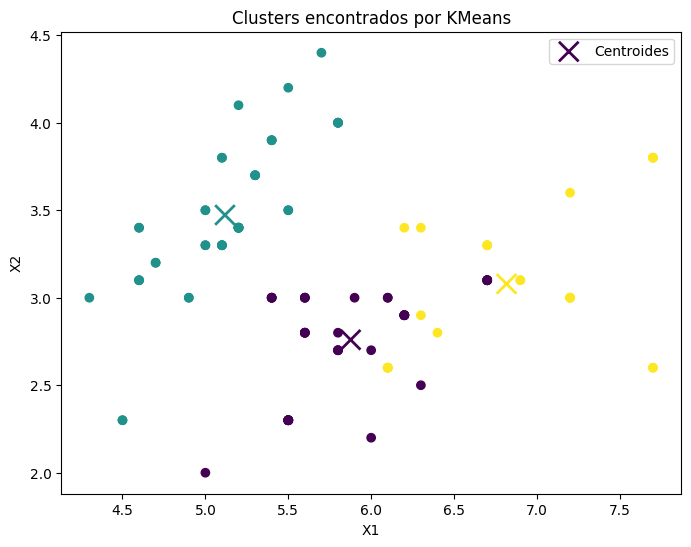

In [13]:
k_means = KMeans(3, 500)

k_means.fit(X_entradas)
k_means.labels
plot_clusters(X_entradas, k_means.labels, k_means.centroides)

In [14]:
def plot_all_pairs(X, labels, centroides=None):
    n_features = X.shape[1]
    fig, axes = plt.subplots(n_features-1, n_features-1, figsize=(12,12))
    axes = np.array(axes)

    for i in range(n_features):
        for j in range(i+1, n_features):
            ax = axes[i, j-1] if n_features > 2 else axes
            ax.scatter(X[:, i], X[:, j], c=labels, cmap='viridis')

            # centroides con mismo color que cluster
            if centroides is not None:
                ax.scatter(
                    centroides[:, i], centroides[:, j],
                    c=np.arange(len(centroides)), cmap='viridis',
                    s=200, marker='x', edgecolor='black', linewidths=2
                )
        
    
    plt.tight_layout()
    plt.show()

/var/folders/20/xpqdbsrj4wb6tc710ddf8s880000gn/T/ipykernel_1214/4116682660.py:13: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


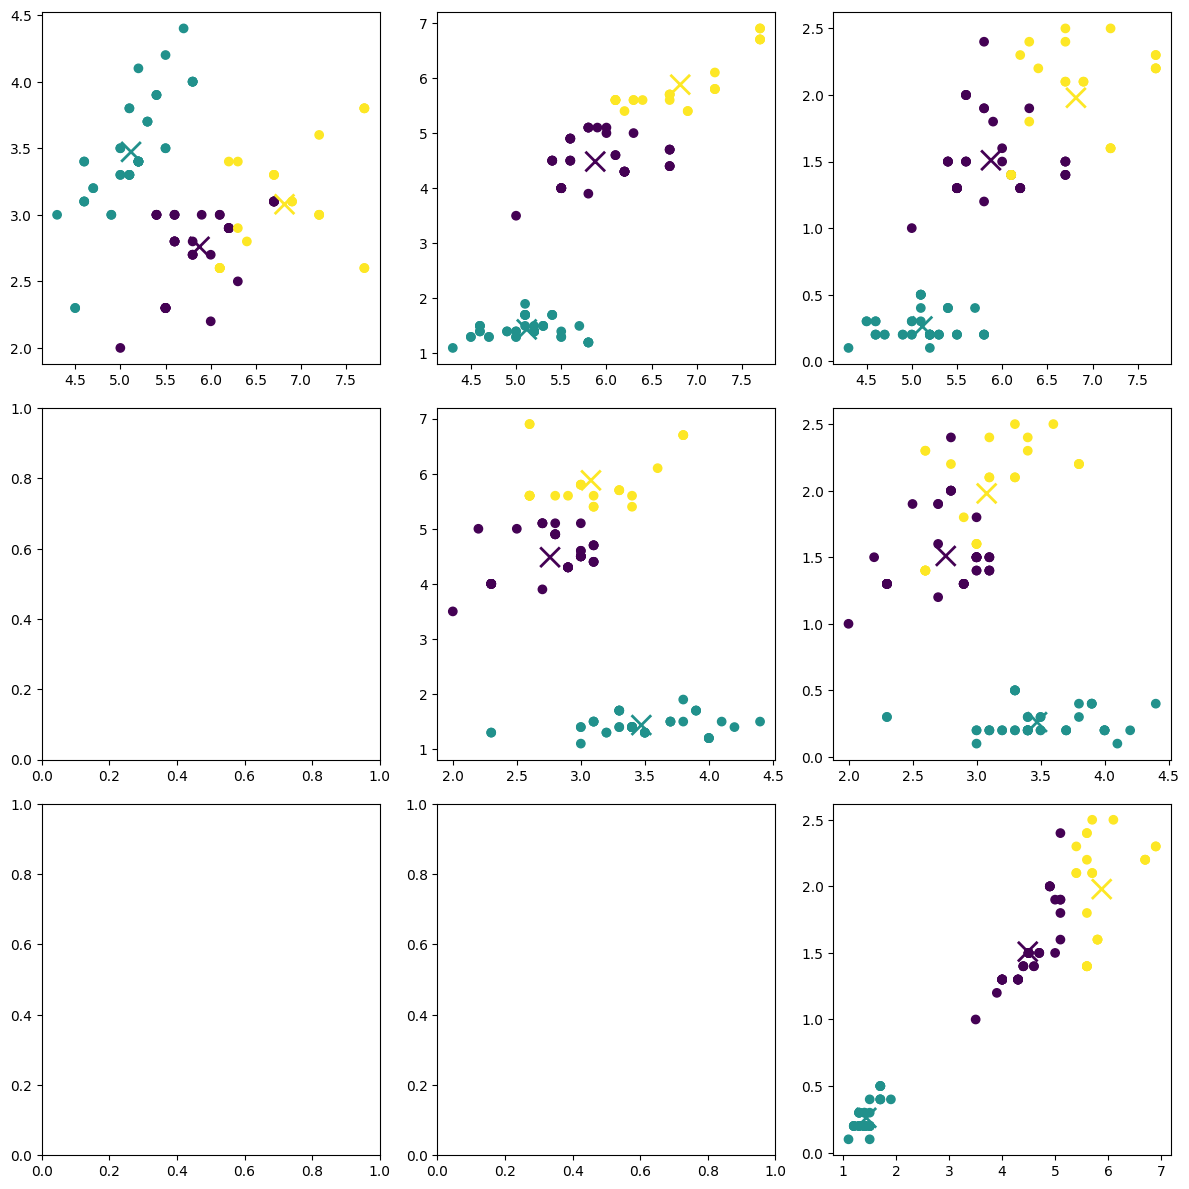

In [15]:

plot_all_pairs(X_entradas, k_means.labels, k_means.centroides)


In [16]:
# Paso 1: Asignar clase dominante a cada cluster
K = k_means.K
clase_por_cluster = np.zeros(K, dtype=int)
for k in range(K):
    indices = np.where(k_means.labels == k)[0]
    if len(indices) > 0:
        clase_por_cluster[k] = np.bincount(y[indices]).argmax()

# Paso 2: Predecir clase para cada muestra según su cluster
y_pred = clase_por_cluster[k_means.labels]

# Paso 3: Calcular aciertos
aciertos = np.sum(y_pred == y)
porcentaje = aciertos / len(y) * 100
print(f'Aciertos: {aciertos} de {len(y)} ({porcentaje:.2f}%)')

Aciertos: 100 de 110 (90.91%)


El entrenamiento finalizó en la época 699 en 29.78 segundos.
El entrenamiento finalizó en la época 999 en 21.07 segundos.
El entrenamiento finalizó en la época 999 en 21.07 segundos.
El entrenamiento finalizó en la época 999 en 0.89 segundos.
El entrenamiento finalizó en la época 999 en 0.89 segundos.


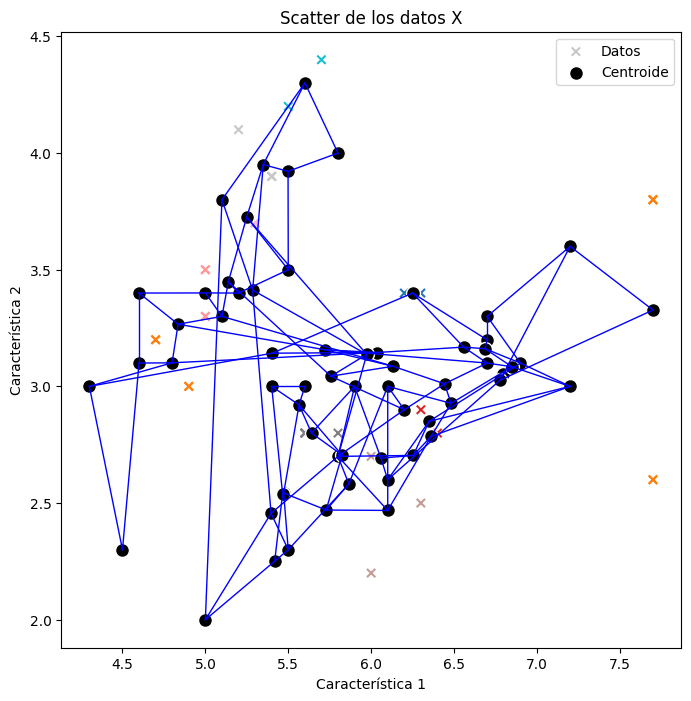

In [11]:

map_size = 8
# Inicializamos los pesos
som = SOM(map_size)

som.fit(X_entradas, 700, [0.9, 0.9], [32, 32])
som.fit(X_entradas, 1000, [0.9, 0.1], [32, 1])
som.fit(X_entradas, 1000, [0.01, 0.01], [0, 0])

som.graficar(X_entradas)



### K-medias vs real

In [17]:

matriz = contingency_matrix(y, k_means.labels)
print(matriz)

[[10  0 24]
 [32  0  0]
 [ 0 44  0]]


* 10 muestras de la clase 0 fueron asignadas al cluster 0 y 24 muestras de la clase 0 fueron asignadas al cluster 3
* 32 muestras de la clase 1 fueron asignadas a la clase 1
* 44  muestras de la clase 2 fueron asignadas al cluster 2

## SOM vs real

In [18]:
input_neuronas = som.obtener_neuronas_ganadoras(X_entradas)
matriz = contingency_matrix(y, input_neuronas)
matriz


array([[0, 0, 2, 2, 2, 1, 5, 0, 0, 2, 0, 0, 3, 2, 5, 0, 0, 0, 0, 0, 2, 2,
        1, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 0, 0, 0, 0, 0, 6, 2, 1, 0,
        0, 0, 0, 1, 0, 0, 8, 0, 0, 0, 1, 4, 3],
       [2, 1, 0, 0, 0, 0, 0, 3, 4, 0, 2, 0, 0, 0, 0, 4, 4, 7, 0, 0, 0, 0,
        0, 2, 4, 0, 0, 4, 0, 4, 2, 1, 0, 0, 0]])

* 5 muestras de la clase 0 fueron clasificadas por la SOM en la neurona 1

In [29]:
# Obtener neuronas ganadoras para cada muestra
input_neuronas = som.obtener_neuronas_ganadoras(X_entradas)
input_neuronas = np.array(input_neuronas)
input_neuronas

array([49, 47,  9, 40, 52, 38, 57,  4, 56,  8, 43,  8, 39, 32,  7, 47, 32,
        5, 21, 36, 41, 22, 32, 25, 35, 62, 32, 19, 24, 41, 35, 52,  0, 19,
        0, 56, 13,  7, 49, 52, 62,  1, 41,  7, 32, 49, 21, 40, 35, 25, 37,
       32, 47, 23, 49,  4, 16,  7, 19, 24, 52, 25, 36,  9, 23,  7, 23, 24,
       57, 37, 56, 35, 52, 52, 62, 23, 63, 52, 32, 35, 35,  5, 19, 22,  9,
       47, 62,  9, 58, 13, 41, 24, 56, 21, 19, 37, 63,  3,  6, 47, 19, 38,
       52, 23,  3, 59, 63,  8, 16, 25])

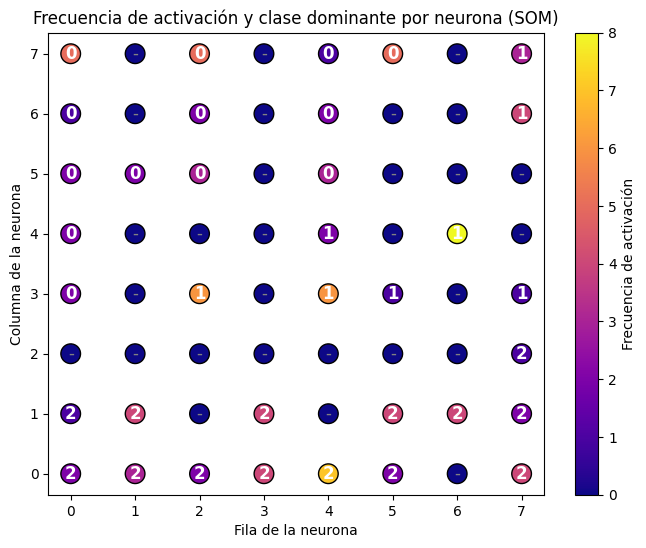

In [21]:


# Obtener neuronas ganadoras para cada muestra
input_neuronas = som.obtener_neuronas_ganadoras(X_entradas)
input_neuronas = np.array(input_neuronas)

# Cantidad de neuronas en el mapa
num_neuronas = som.w.shape[0] * som.w.shape[1]

# Frecuencia de activación de cada neurona
frecuencias = np.bincount(input_neuronas, minlength=num_neuronas)

# Clase dominante por neurona
clase_dominante = np.full(num_neuronas, -1)
for i in range(num_neuronas):
    indices = np.where(input_neuronas == i)[0]
    if len(indices) > 0:
        clase_dominante[i] = np.bincount(y[indices]).argmax()

# Posiciones 2D de las neuronas
posiciones = np.array([np.unravel_index(i, (som.w.shape[0], som.w.shape[1])) for i in range(num_neuronas)])

plt.figure(figsize=(8,6))
sc = plt.scatter(posiciones[:,0], posiciones[:,1], c=frecuencias, cmap='plasma', s=200, edgecolor='black')
plt.colorbar(sc, label='Frecuencia de activación')

# Marcar la clase dominante en cada neurona
for i, (x, y_) in enumerate(posiciones):
    if clase_dominante[i] != -1:
        plt.text(x, y_, str(clase_dominante[i]), color='white', ha='center', va='center', fontsize=12, fontweight='bold')
    else:
        plt.text(x, y_, '-', color='gray', ha='center', va='center', fontsize=12)

plt.xlabel('Fila de la neurona')
plt.ylabel('Columna de la neurona')
plt.title('Frecuencia de activación y clase dominante por neurona (SOM)')
plt.show()

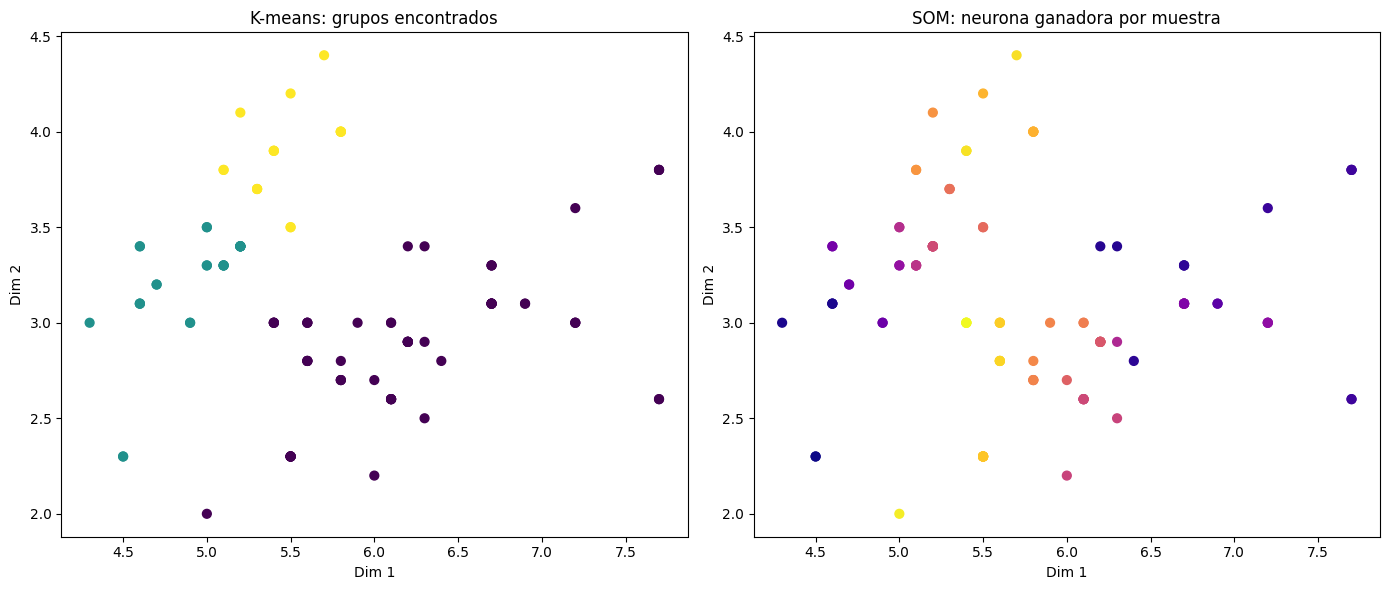

In [118]:
# Seleccionar dos dimensiones (por ejemplo, las dos primeras)
dim1, dim2 = 0, 1

plt.figure(figsize=(14,6))

# Grupos de K-means
plt.subplot(1,2,1)
plt.scatter(X_entradas[:,dim1], X_entradas[:,dim2], c=k_means.labels, cmap='viridis', s=40)
plt.xlabel(f'Dim {dim1+1}')
plt.ylabel(f'Dim {dim2+1}')
plt.title('K-means: grupos encontrados')

# Grupos de SOM (neurona ganadora)
plt.subplot(1,2,2)
input_neuronas = som.obtener_neuronas_ganadoras(X_entradas)
plt.scatter(X_entradas[:,dim1], X_entradas[:,dim2], c=input_neuronas, cmap='plasma', s=40)
plt.xlabel(f'Dim {dim1+1}')
plt.ylabel(f'Dim {dim2+1}')
plt.title('SOM: neurona ganadora por muestra')

plt.tight_layout()
plt.show()